### 1. 환경 설정 및 상태 추적기

구글 드라이브를 연결하고, 5개의 압축 파일 경로와 학습 상태를 저장할 JSON 파일 경로를 설정합니다.

In [ ]:
import os
import json
import glob
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive', force_remount=True)

# 2. 경로 설정
BASE_DIR = '/content/drive/MyDrive/UNet'

# 소음 데이터 폴더 내의 모든 zip 파일을 자동으로 리스트업합니다.
NOISE_ZIPS = glob.glob(f'{BASE_DIR}/Noise/TS_*.zip')

# 5개의 목소리 데이터 압축 파일 리스트
VOICE_ZIPS = [
    f'{BASE_DIR}/Korean_Voice/KsponSpeech_01.zip',
    f'{BASE_DIR}/Korean_Voice/KsponSpeech_02.zip',
    f'{BASE_DIR}/Korean_Voice/KsponSpeech_03.zip',
    f'{BASE_DIR}/Korean_Voice/KsponSpeech_04.zip',
    f'{BASE_DIR}/Korean_Voice/KsponSpeech_05.zip'
]

# 체크포인트 및 상태 저장 경로
CHECKPOINT_DIR = f'{BASE_DIR}/Checkpoints'
STATE_FILE = f'{CHECKPOINT_DIR}/training_state.json'

if not os.path.exists(CHECKPOINT_DIR):
    os.makedirs(CHECKPOINT_DIR)

# 3. 상태 관리 함수
def load_state():
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE, 'r') as f:
            return json.load(f)
    return {"current_zip_idx": 0, "current_epoch": 0}

def save_state(zip_idx, epoch):
    state = {"current_zip_idx": zip_idx, "current_epoch": epoch}
    with open(STATE_FILE, 'w') as f:
        json.dump(state, f)
    print(f"💾 학습 상태 저장 완료: [Zip {zip_idx+1}/{len(VOICE_ZIPS)}], [Epoch {epoch}]")

print(f"환경 설정 완료 (발견된 소음 파일: {len(NOISE_ZIPS)}개)")

Mounted at /content/drive
환경 설정 완료 (발견된 소음 파일: 10개)


### 2. 모델 및 오디오 전처리 함수 정의

U-Net 모델 구조와 스펙트로그램 변환(STFT/ISTFT) 함수를 정의합니다.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNetMasker(nn.Module):
    def __init__(self):
        super(UNetMasker, self).__init__()
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
        self.dec1 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x):
        e1 = F.relu(self.enc1(x))
        e2 = F.relu(self.enc2(self.pool(e1)))
        d2 = F.relu(self.dec2(self.up(e2)))

        if d2.size() != e1.size():
            d2 = F.interpolate(d2, size=e1.shape[2:])

        mask = torch.sigmoid(self.dec1(d2))
        return x * mask, mask

def get_spec(audio):
    # 경고 해결을 위해 hann_window 적용
    window = torch.hann_window(512).to(audio.device)
    spec = torch.stft(audio.squeeze(1), n_fft=512, hop_length=160, window=window, return_complex=True, center=True)
    return torch.abs(spec), torch.angle(spec)

print("모델 및 전처리 함수 정의 완료.")

모델 및 전처리 함수 정의 완료.


### 3. 디스크 관리 및 데이터 로더 정의

압축 해제 후 삭제를 통한 디스크 용량 관리 로직과 4초 이상(128KB) 데이터 필터링 로직을 포함합니다.

In [ ]:
import glob
import zipfile
import shutil
import random
import numpy as np
import librosa
from torch.utils.data import Dataset, DataLoader

TEMP_VOICE_DIR = '/content/temp_voice'
TEMP_NOISE_DIR = '/content/temp_noise'

def manage_disk_and_extract(zip_path, extract_dir):
    if os.path.exists(extract_dir):
        shutil.rmtree(extract_dir)
        print(f"🗑️ 기존 임시 폴더 삭제 완료: {extract_dir}")

    os.makedirs(extract_dir)
    print(f"📦 압축 해제 중... ({os.path.basename(zip_path)})")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("✅ 압축 해제 완료.")

class RobustDataset(Dataset):
    def __init__(self, voice_dir, noise_dir, samples=64000):
        all_voices = glob.glob(os.path.join(voice_dir, '**', '*.pcm'), recursive=True)
        self.voice_list = [f for f in all_voices if os.path.getsize(f) >= samples * 2]

        self.noise_list = glob.glob(os.path.join(noise_dir, '**', '*.mp3'), recursive=True)
        self.samples = samples
        print(f"📊 데이터 로드: 목소리 {len(self.voice_list)}개, 소음 {len(self.noise_list)}개 준비됨.")

    def load_pcm(self, path):
        try:
            with open(path, 'rb') as f:
                return np.frombuffer(f.read(), dtype=np.int16).astype(np.float32) / 32768.0
        except:
            return np.zeros(self.samples)

    def __len__(self):
        return len(self.voice_list)

    def __getitem__(self, idx):
        v_path = self.voice_list[idx]
        v_data = self.load_pcm(v_path)
        if len(v_data) < self.samples: return torch.zeros(1, self.samples), torch.zeros(1, self.samples)

        start = np.random.randint(0, len(v_data) - self.samples + 1)
        clean = v_data[start : start + self.samples]

        n_path = random.choice(self.noise_list)
        try:
            noise, _ = librosa.load(n_path, sr=16000, offset=8.5, duration=6.0)
            # 파일이 8.5초보다 짧은 경우 처음부터 다시 로드
            if len(noise) == 0:
                noise, _ = librosa.load(n_path, sr=16000, duration=6.0)
            # 여전히 비어있으면 0으로 채움
            if len(noise) == 0:
                noise = np.zeros(self.samples)
        except:
            noise = np.zeros(self.samples)

        if len(noise) < self.samples:
            noise = np.tile(noise, int(np.ceil(self.samples / len(noise))))
        start_n = np.random.randint(0, len(noise) - self.samples + 1)
        noise = noise[start_n : start_n + self.samples]

        snr = np.random.uniform(5, 15)
        clean_rms = np.sqrt(np.mean(clean**2) + 1e-9)
        noise_rms = np.sqrt(np.mean(noise**2) + 1e-9)
        noise = noise * (clean_rms / (10**(snr/20)) / noise_rms)

        noisy = clean + noise
        return torch.FloatTensor(noisy).unsqueeze(0), torch.FloatTensor(clean).unsqueeze(0)

print("디스크 관리자 및 데이터셋 클래스 준비 완료.")

디스크 관리자 및 데이터셋 클래스 준비 완료.


### 4. 자동 복구 기반 메인 학습 루프

상태 파일을 읽어와 이전 학습이 멈춘 지점(압축 파일 순번 및 에포크)부터 정확히 이어서 학습을 재개합니다.

In [ ]:
import torch.optim as optim
import zipfile

BATCH_SIZE = 64
EPOCHS_PER_ZIP = 10
LEARNING_RATE = 1e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetMasker().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

state = load_state()
start_zip_idx = state['current_zip_idx']
start_epoch = state['current_epoch']

latest_checkpoint = os.path.join(CHECKPOINT_DIR, 'latest_model.pth')
if os.path.exists(latest_checkpoint):
    checkpoint = torch.load(latest_checkpoint, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"🔄 이전 학습 상태 복구됨. (시작 위치: Zip {start_zip_idx+1}/{len(VOICE_ZIPS)}, Epoch {start_epoch+1})")
else:
    print("🆕 저장된 체크포인트가 없습니다. 처음부터 학습을 시작합니다.")

if not os.path.exists(TEMP_NOISE_DIR):
    os.makedirs(TEMP_NOISE_DIR)
    for noise_zip in NOISE_ZIPS:
        print(f"📦 소음 압축 해제 중... ({os.path.basename(noise_zip)})")
        with zipfile.ZipFile(noise_zip, 'r') as zip_ref:
            zip_ref.extractall(TEMP_NOISE_DIR)
    print("✅ 모든 소음 파일 압축 해제 완료.")

for zip_idx in range(start_zip_idx, len(VOICE_ZIPS)):
    current_zip_path = VOICE_ZIPS[zip_idx]

    manage_disk_and_extract(current_zip_path, TEMP_VOICE_DIR)
    dataset = RobustDataset(TEMP_VOICE_DIR, TEMP_NOISE_DIR)
    # num_workers를 코랩 권장 수치인 2로 변경
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

    epochs_to_run = range(start_epoch, EPOCHS_PER_ZIP)
    start_epoch = 0

    for epoch in epochs_to_run:
        model.train()
        total_loss = 0

        print(f"🚀 [Zip {zip_idx+1}/{len(VOICE_ZIPS)}] - Epoch [{epoch+1}/{EPOCHS_PER_ZIP}] 시작")

        for i, (noisy, clean) in enumerate(dataloader):
            noisy, clean = noisy.to(device), clean.to(device)

            noisy_mag, _ = get_spec(noisy)
            clean_mag, _ = get_spec(clean)
            noisy_mag, clean_mag = noisy_mag.unsqueeze(1), clean_mag.unsqueeze(1)

            denoised_mag, _ = model(noisy_mag)
            loss = criterion(denoised_mag, clean_mag)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if (i+1) % 100 == 0:
                print(f"  Step [{i+1}/{len(dataloader)}] Loss: {loss.item():.6f}")

        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        }, latest_checkpoint)

        save_state(zip_idx, epoch + 1)
        print(f"✅ [Zip {zip_idx+1}/{len(VOICE_ZIPS)}] - Epoch {epoch+1} 완료. (Avg Loss: {total_loss / len(dataloader):.6f})")

print("🎉 모든 데이터셋에 대한 학습이 완료되었습니다!")

🔄 이전 학습 상태 복구됨. (시작 위치: Zip 5/5, Epoch 11)
📦 소음 압축 해제 중... (TS_1.자연.zip)
📦 소음 압축 해제 중... (TS_10.기계 및 공구.zip)
📦 소음 압축 해제 중... (TS_2.무기.zip)
📦 소음 압축 해제 중... (TS_3.사람.zip)
📦 소음 압축 해제 중... (TS_4.동물.zip)
📦 소음 압축 해제 중... (TS_5.알람.zip)
📦 소음 압축 해제 중... (TS_6.물체.zip)
📦 소음 압축 해제 중... (TS_7.악기.zip)
📦 소음 압축 해제 중... (TS_8.군부대 운송수단.zip)
📦 소음 압축 해제 중... (TS_9.생활.zip)
✅ 모든 소음 파일 압축 해제 완료.
📦 압축 해제 중... (KsponSpeech_05.zip)
✅ 압축 해제 완료.
📊 데이터 로드: 목소리 65285개, 소음 35848개 준비됨.
🎉 모든 데이터셋에 대한 학습이 완료되었습니다!


결과 검증 및 시각화

Mounted at /content/drive
✅ 불러올 모델: latest_model.pth
테스트용 목소리 추출 중 (4초 이상 검색)...
테스트용 소음 추출 중...
🔊 테스트 파일 생성 완료: 목소리(KsponSpeech_045520.pcm) + 소음(S-211027_I_205_C_074_0001.mp3)


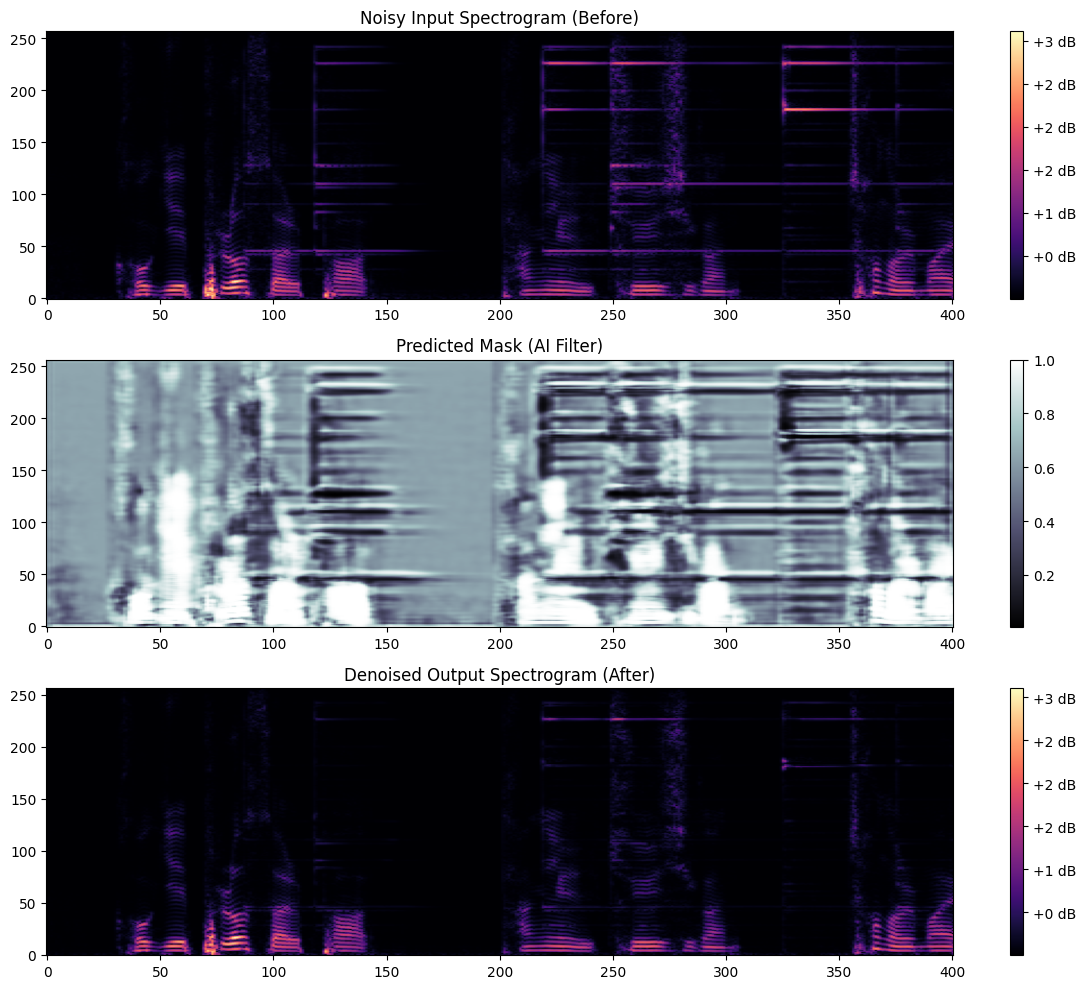

📊 스펙트로그램 이미지 저장 완료: /content/drive/MyDrive/UNet/Test_Results/result_spectrogram.png
🎧 오디오 파일 저장 완료 (noisy, denoised, clean): /content/drive/MyDrive/UNet/Test_Results 폴더 확인


In [4]:
import os
import glob
import random
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive', force_remount=True)

# 2. 경로 설정
BASE_DIR = '/content/drive/MyDrive/UNet'
CHECKPOINT_DIR = f'{BASE_DIR}/Checkpoints'
RESULT_DIR = f'{BASE_DIR}/Test_Results'

if not os.path.exists(RESULT_DIR):
    os.makedirs(RESULT_DIR)

VOICE_ZIP = f'{BASE_DIR}/Korean_Voice/KsponSpeech_01.zip'
NOISE_ZIPS = glob.glob(f'{BASE_DIR}/Noise/TS_*.zip')

# 3. 모델 및 전처리 함수 정의
class UNetMasker(nn.Module):
    def __init__(self):
        super(UNetMasker, self).__init__()
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
        self.dec1 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x):
        e1 = F.relu(self.enc1(x))
        e2 = F.relu(self.enc2(self.pool(e1)))
        d2 = F.relu(self.dec2(self.up(e2)))
        if d2.size() != e1.size():
            d2 = F.interpolate(d2, size=e1.shape[2:])
        mask = torch.sigmoid(self.dec1(d2))
        return x * mask, mask

def get_spec(audio):
    window = torch.hann_window(512).to(audio.device)
    spec = torch.stft(audio.squeeze(1), n_fft=512, hop_length=160, window=window, return_complex=True, center=True)
    return torch.abs(spec), torch.angle(spec)

def spec_to_wav(mag, phase):
    complex_spec = torch.polar(mag, phase)
    return torch.istft(complex_spec, n_fft=512, hop_length=160, center=True)

# 4. 테스트용 샘플 추출 함수
def get_random_test_samples(voice_zip, noise_zips, temp_dir='/content/temp_test'):
    if not os.path.exists(temp_dir): os.makedirs(temp_dir)

    print("테스트용 목소리 추출 중 (4초 이상 검색)...")
    with zipfile.ZipFile(voice_zip, 'r') as z:
        min_bytes = 16000 * 2 * 4
        valid_infos = [info for info in z.infolist() if info.filename.endswith('.pcm') and info.file_size >= min_bytes]
        target_info = random.choice(valid_infos)
        z.extract(target_info, temp_dir)
        voice_path = os.path.join(temp_dir, target_info.filename)

    print("테스트용 소음 추출 중...")
    noise_zip = random.choice(noise_zips)
    with zipfile.ZipFile(noise_zip, 'r') as z:
        mp3_files = [f for f in z.namelist() if f.endswith('.mp3')]
        target_mp3 = random.choice(mp3_files)
        z.extract(target_mp3, temp_dir)
        noise_path = os.path.join(temp_dir, target_mp3)

    return voice_path, noise_path

# 5. 메인 실행 및 시각화 로직
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

latest_checkpoint = os.path.join(CHECKPOINT_DIR, 'latest_model.pth')
if not os.path.exists(latest_checkpoint):
    print(f"❌ 오류: {latest_checkpoint} 파일이 없습니다. 학습이 완료되었는지 확인하세요.")
else:
    print(f"✅ 불러올 모델: {os.path.basename(latest_checkpoint)}")

    model = UNetMasker().to(device)
    checkpoint = torch.load(latest_checkpoint, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    v_path, n_path = get_random_test_samples(VOICE_ZIP, NOISE_ZIPS)

    with open(v_path, 'rb') as f:
        clean = np.frombuffer(f.read(), dtype=np.int16).astype(np.float32) / 32768.0

    try:
        noise, _ = librosa.load(n_path, sr=16000, offset=8.5, duration=6.0)
        if len(noise) == 0:
            noise, _ = librosa.load(n_path, sr=16000, duration=6.0)
        if len(noise) == 0:
            noise = np.zeros(16000 * 4)
    except:
        noise = np.zeros(16000 * 4)

    sample_len = 16000 * 4
    clean = clean[:sample_len]

    if len(noise) >= sample_len:
        noise = noise[:sample_len]
    else:
        noise = np.resize(noise, sample_len)

    noisy = clean + noise * 0.5
    print(f"🔊 테스트 파일 생성 완료: 목소리({os.path.basename(v_path)}) + 소음({os.path.basename(n_path)})")

    with torch.no_grad():
        noisy_t = torch.FloatTensor(noisy).unsqueeze(0).unsqueeze(0)
        mag, phase = get_spec(noisy_t)

        mag = mag.unsqueeze(1).to(device)

        denoised_mag, mask = model(mag)
        denoised_wav = spec_to_wav(denoised_mag.squeeze(1).cpu(), phase)

    plt.figure(figsize=(12, 10))

    plt.subplot(3, 1, 1)
    plt.title("Noisy Input Spectrogram (Before)")
    plt.imshow(torch.log1p(mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower', cmap='magma')
    plt.colorbar(format='%+2.0f dB')

    plt.subplot(3, 1, 2)
    plt.title("Predicted Mask (AI Filter)")
    plt.imshow(mask.squeeze().cpu().numpy(), aspect='auto', origin='lower', cmap='bone')
    plt.colorbar()

    plt.subplot(3, 1, 3)
    plt.title("Denoised Output Spectrogram (After)")
    plt.imshow(torch.log1p(denoised_mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower', cmap='magma')
    plt.colorbar(format='%+2.0f dB')

    plt.tight_layout()

    save_img_path = os.path.join(RESULT_DIR, 'result_spectrogram.png')
    plt.savefig(save_img_path)
    plt.show()
    print(f"📊 스펙트로그램 이미지 저장 완료: {save_img_path}")

    sf.write(os.path.join(RESULT_DIR, 'test_noisy.wav'), noisy, 16000)
    sf.write(os.path.join(RESULT_DIR, 'test_denoised.wav'), denoised_wav[0].numpy(), 16000)
    sf.write(os.path.join(RESULT_DIR, 'test_clean.wav'), clean, 16000)
    print(f"🎧 오디오 파일 저장 완료 (noisy, denoised, clean): {RESULT_DIR} 폴더 확인")

## 테스트용 코드
아래는 테스트용을 사용했던 코드

더 이상 사용 안함

### 1. 환경 설정 및 데이터 로컬 추출

구글 드라이브 마운트 후, 목소리와 소음 데이터를 각각 한 폴더씩 로컬(/content/)로 가져옵니다.

In [ ]:
# import os
# import zipfile
# import json
# import librosa
# import numpy as np
# import torch
# import matplotlib.pyplot as plt
# from torch.utils.data import Dataset, DataLoader
# from google.colab import drive

# # 1. 드라이브 마운트
# drive.mount('/content/drive')

# # 2. 경로 설정
# VOICE_ZIP = '/content/drive/MyDrive/UNet/Korean_Voice/KsponSpeech_01.zip'
# NOISE_ZIP = '/content/drive/MyDrive/UNet/Noise/TS_1.자연.zip'
# LABEL_ZIP = '/content/drive/MyDrive/UNet/Noise/TL_1.자연.zip'

# EXTRACT_VOICE = '/content/voice_sample/'
# EXTRACT_NOISE = '/content/noise_sample/'
# EXTRACT_LABEL = '/content/label_sample/'

# # 추출할 타겟 폴더 (사용자 이미지 기반 구조)
# TARGET_VOICE_DIR = 'KsponSpeech_01/KsponSpeech_0001'
# TARGET_NOISE_DIR = '1.기상/1.비'

# def select_extract(zip_path, target_dir, save_path):
#     if not os.path.exists(save_path): os.makedirs(save_path)
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         target_files = [f for f in zip_ref.namelist() if f.startswith(target_dir)]
#         for file in target_files:
#             zip_ref.extract(file, save_path)
#     print(f"{target_dir} 추출 완료!")

# # 실행
# select_extract(VOICE_ZIP, TARGET_VOICE_DIR, EXTRACT_VOICE)
# select_extract(NOISE_ZIP, TARGET_NOISE_DIR, EXTRACT_NOISE)
# select_extract(LABEL_ZIP, TARGET_NOISE_DIR, EXTRACT_LABEL)

### 2. 4초 이상 음성 파일 필터링

앞서 수행했던 대로 4초 이상의 PCM 파일들만 리스트업합니다.

In [ ]:
# sample_rate = 16000
# duration_sec = 4.0
# limit_size = int(sample_rate * 2 * duration_sec) # 16bit = 2bytes

# voice_folder = os.path.join(EXTRACT_VOICE, TARGET_VOICE_DIR)
# all_voices = [os.path.join(voice_folder, f) for f in os.listdir(voice_folder) if f.endswith('.pcm')]
# valid_voices = [f for f in all_voices if os.path.getsize(f) >= limit_size]

# print(f"학습 가능 목소리 샘플 수: {len(valid_voices)}")

### 3. 통합 데이터 로더 (TTS 제거 및 합성 로직 포함)

소음의 TTS 구간을 JSON 정보를 이용해 자동으로 잘라내고 합성하는 클래스입니다.

In [ ]:
# class DenoisingDataset(Dataset):
#     def __init__(self, voice_list, noise_dir, label_dir, samples=64000): # 4초 = 64000 samples
#         self.voice_list = voice_list
#         self.noise_files = [f for f in os.listdir(os.path.join(noise_dir, TARGET_NOISE_DIR)) if f.endswith('.mp3')]
#         self.noise_dir = os.path.join(noise_dir, TARGET_NOISE_DIR)
#         self.label_dir = os.path.join(label_dir, TARGET_NOISE_DIR)
#         self.samples = samples

#     def load_pcm(self, path):
#         with open(path, 'rb') as f:
#             return np.frombuffer(f.read(), dtype=np.int16).astype(np.float32) / 32768.0

#     def __len__(self):
#         return len(self.voice_list)

#     def __getitem__(self, idx):
#         # 1. 목소리 로드 및 4초 커팅
#         v_audio = self.load_pcm(self.voice_list[idx])
#         start_v = np.random.randint(0, len(v_audio) - self.samples + 1)
#         clean = v_audio[start_v : start_v + self.samples]

#         # 2. 소음 로드 (JSON 기반 TTS 제거)
#         n_file = np.random.choice(self.noise_files)
#         n_path = os.path.join(self.noise_dir, n_file)
#         l_path = os.path.join(self.label_dir, n_file.replace('.mp3', '.json'))

#         try:
#             with open(l_path, 'r', encoding='utf-8') as f:
#                 l_data = json.load(f)
#             # TTS가 끝나는 첫 번째 Segmentation 시작점 사용
#             offset = l_data['LabelDataInfo']['Segmentations'][0][0]
#         except:
#             offset = 8.5 # JSON 로드 실패 시 기본 TTS 길이 가정

#         # 리샘플링 포함 로드 (16kHz)
#         noise, _ = librosa.load(n_path, sr=16000, offset=offset, duration=8.0)

#         # 소음 길이 맞추기
#         if len(noise) < self.samples:
#             noise = np.tile(noise, int(np.ceil(self.samples / len(noise))))
#         start_n = np.random.randint(0, len(noise) - self.samples + 1)
#         noise = noise[start_n : start_n + self.samples]

#         # 3. SNR 랜덤 합성 (5~15dB)
#         snr = np.random.uniform(5, 15)
#         clean_rms = np.sqrt(np.mean(clean**2) + 1e-8)
#         noise_rms = np.sqrt(np.mean(noise**2) + 1e-8)
#         noise = noise * (clean_rms / (10**(snr/20)) / noise_rms)

#         noisy = clean + noise

#         return torch.FloatTensor(noisy).unsqueeze(0), torch.FloatTensor(clean).unsqueeze(0)

# # 데이터로더 생성
# dataset = DenoisingDataset(valid_voices, EXTRACT_NOISE, EXTRACT_LABEL)
# dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

### 4. 합성 결과 시각화 확인

모델에 들어가기 전, 실제로 소음이 TTS 없이 잘 섞였는지 한 쌍을 뽑아 확인합니다.

In [ ]:
# noisy_sample, clean_sample = next(iter(dataloader))

# plt.figure(figsize=(12, 6))
# plt.subplot(2, 1, 1)
# plt.plot(noisy_sample[0, 0].numpy())
# plt.title("Noisy Input (Voice + Pure Noise)")

# plt.subplot(2, 1, 2)
# plt.plot(clean_sample[0, 0].numpy())
# plt.title("Clean Target (Original Voice)")
# plt.tight_layout()
# plt.show()

In [ ]:
# import soundfile as sf

# 데이터로더에서 샘플 하나 가져오기
# noisy_batch, clean_batch = next(iter(dataloader))
# sample_noisy = noisy_batch[0, 0].numpy()  # 첫 번째 샘플의 오디오 데이터

# 파일로 저장 (코랩 왼쪽 파일 탭에서 확인 가능)
# output_path = '/content/check_mixed_audio.wav'
# sf.write(output_path, sample_noisy, 16000)

# print(f"합성된 샘플이 {output_path}에 저장되었습니다. 다운로드해서 들어보세요!")

In [ ]:
# sample_noisy = clean_batch[0, 0].numpy()  # 첫 번째 샘플의 오디오 데이터

# 파일로 저장 (코랩 왼쪽 파일 탭에서 확인 가능)
# output_path = '/content/check_clear_audio.wav'
# sf.write(output_path, sample_noisy, 16000)

# print(f"합성된 샘플이 {output_path}에 저장되었습니다. 다운로드해서 들어보세요!")

### U-Net 모델 정의 및 학습 실행

​이 코드는 앞서 정의한 dataloader를 사용하여 실제로 모델을 학습시키고, 학습된 모델로 소음 제거 테스트까지 수행합니다.

In [ ]:
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F

# # --- 1. U-Net 모델 정의 (계획서의 마스크 생성 부분) ---
# class UNetMasker(nn.Module):
#     def __init__(self):
#         super(UNetMasker, self).__init__()
#         # Encoder
#         self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
#         self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.pool = nn.MaxPool2d(2)

#         # Decoder
#         self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
#         self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
#         self.dec1 = nn.Conv2d(32, 1, 3, padding=1)

#     def forward(self, x):
#         # x shape: [Batch, 1, Freq, Time]
#         e1 = F.relu(self.enc1(x))
#         e2 = F.relu(self.enc2(self.pool(e1)))

#         d2 = F.relu(self.dec2(self.up(e2)))

#         # Skip Connection (e1과 크기 맞추기 위해 보정 필요할 수 있음)
#         if d2.size() != e1.size():
#             d2 = F.interpolate(d2, size=e1.shape[2:])

#         mask = torch.sigmoid(self.dec1(d2)) # 0~1 사이의 마스크 출력

#         # 마스킹: 원본(Noisy) * 마스크 = Denoised
#         return x * mask, mask

In [ ]:
# # --- 2. STFT/ISTFT 변환 함수 (계획서 2번 항목) ---
# def get_spec(audio):
#     # audio: [Batch, 1, Samples] -> [Batch, 1, Freq, Time]
#     spec = torch.stft(audio.squeeze(1), n_fft=512, hop_length=160,
#                       return_complex=True, center=True)
#     return torch.abs(spec), torch.angle(spec)

# def spec_to_wav(mag, phase):
#     complex_spec = torch.polar(mag, phase)
#     return torch.istft(complex_spec, n_fft=512, hop_length=160, center=True)

In [ ]:
# # --- 3. 학습 루프 (Training Loop) ---
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = UNetMasker().to(device)
# optimizer = optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.MSELoss()

# print(f"학습 시작 (Device: {device})")
# epochs = 5  # 테스트용으로 짧게 설정

# for epoch in range(epochs):
#     model.train()
#     total_loss = 0

#     for i, (noisy, clean) in enumerate(dataloader):
#         noisy, clean = noisy.to(device), clean.to(device)

#         # STFT 변환
#         noisy_mag, noisy_phase = get_spec(noisy)
#         clean_mag, _ = get_spec(clean)

#         # 모델 입력 (Magnitude만 사용)
#         noisy_mag = noisy_mag.unsqueeze(1) # Channel dimension 추가
#         clean_mag = clean_mag.unsqueeze(1)

#         # 예측 및 Loss 계산
#         denoised_mag, mask = model(noisy_mag)
#         loss = criterion(denoised_mag, clean_mag)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(dataloader):.6f}")

# print("학습 완료!")

In [ ]:
# import os
# import soundfile as sf

# # --- 4. 결과 확인 및 드라이브 저장 (수정됨) ---
# # 저장할 드라이브 경로 설정
# save_dir = '/content/drive/MyDrive/UNet/Results'
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)
#     print(f"폴더 생성 완료: {save_dir}")

# # 모델을 평가 모드로 전환
# model.eval()

# with torch.no_grad():
#     # 테스트용 샘플 하나 가져오기
#     test_noisy, test_clean = next(iter(dataloader))
#     test_noisy = test_noisy.to(device)

#     # 모델 추론 (소음 제거 시도)
#     n_mag, n_phase = get_spec(test_noisy)
#     pred_mag, _ = model(n_mag.unsqueeze(1)) # 마스크 생성 및 노이즈 제거

#     # 파형 복원 (ISTFT)
#     pred_wav = spec_to_wav(pred_mag.squeeze(1), n_phase)

# # 구글 드라이브에 파일 저장
# # 1. 모델이 복원한 소리 (Denoised)
# sf.write(os.path.join(save_dir, 'result_denoised.wav'), pred_wav[0].cpu().numpy(), 16000)

# # 2. 원래 소음 섞인 소리 (Noisy Input - 비교용)
# sf.write(os.path.join(save_dir, 'result_noisy.wav'), test_noisy[0,0].cpu().numpy(), 16000)

# # 3. 정답 깨끗한 소리 (Clean Target - 비교용)
# sf.write(os.path.join(save_dir, 'result_clean.wav'), test_clean[0,0].cpu().numpy(), 16000)

# print(f"저장 완료! 구글 드라이브의 [{save_dir}] 폴더를 확인해보세요.")

윗부분 없애고 별개로 실행

In [ ]:
# import os
# import glob
# import zipfile
# import random
# import numpy as np
# import librosa
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# from google.colab import drive

# # 1. 구글 드라이브 마운트
# drive.mount('/content/drive')

# # --- 설정 (경로 및 파라미터) ---
# VOICE_ZIP = '/content/drive/MyDrive/UNet/Korean_Voice/KsponSpeech_01.zip'
# NOISE_ZIP = '/content/drive/MyDrive/UNet/Noise/TS_1.자연.zip'
# LABEL_ZIP = '/content/drive/MyDrive/UNet/Noise/TL_1.자연.zip'

# EXTRACT_VOICE_DIR = '/content/voices_full/'
# EXTRACT_NOISE_DIR = '/content/noises_full/'
# CHECKPOINT_DIR = '/content/drive/MyDrive/UNet/Checkpoints'

# BATCH_SIZE = 32
# EPOCHS = 50
# LEARNING_RATE = 1e-4

# if not os.path.exists(CHECKPOINT_DIR):
#     os.makedirs(CHECKPOINT_DIR)

# # --- 2. 데이터 압축 해제 (최초 1회 수행) ---
# def extract_all(zip_path, extract_to):
#     if not os.path.exists(extract_to):
#         os.makedirs(extract_to)
#         print(f"압축 해제 중... (시간이 좀 걸립니다): {zip_path}")
#         with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#             zip_ref.extractall(extract_to)
#         print("압축 해제 완료!")
#     else:
#         print(f"이미 폴더가 있어 압축 해제를 건너뜁니다: {extract_to}")

# extract_all(VOICE_ZIP, EXTRACT_VOICE_DIR)
# extract_all(NOISE_ZIP, EXTRACT_NOISE_DIR)
# # 라벨은 데이터 로더에서 파일명 매칭 규칙(8.5초 룰)을 쓸 것이므로 굳이 안 풀어도 됩니다.

# # --- 3. 데이터셋 클래스 정의 ---
# class RobustDataset(Dataset):
#     def __init__(self, voice_dir, noise_dir, samples=64000):
#         # 파일 리스트업 (재귀 탐색)
#         self.voice_list = glob.glob(os.path.join(voice_dir, '**', '*.pcm'), recursive=True)
#         # 4초(128KB) 이상만 필터링
#         self.voice_list = [f for f in self.voice_list if os.path.getsize(f) >= samples * 2]

#         self.noise_list = glob.glob(os.path.join(noise_dir, '**', '*.mp3'), recursive=True)
#         self.samples = samples
#         print(f"학습 데이터 준비 완료: 목소리 {len(self.voice_list)}개, 소음 {len(self.noise_list)}개")

#     def load_pcm(self, path):
#         try:
#             with open(path, 'rb') as f:
#                 return np.frombuffer(f.read(), dtype=np.int16).astype(np.float32) / 32768.0
#         except:
#             return np.zeros(self.samples)

#     def __len__(self):
#         return len(self.voice_list)

#     def __getitem__(self, idx):
#         # 목소리 로드
#         v_path = self.voice_list[idx]
#         v_data = self.load_pcm(v_path)
#         if len(v_data) < self.samples: return torch.zeros(1, self.samples), torch.zeros(1, self.samples)

#         start = np.random.randint(0, len(v_data) - self.samples + 1)
#         clean = v_data[start : start + self.samples]

#         # 소음 로드 (랜덤)
#         n_path = random.choice(self.noise_list)
#         try:
#             # TTS 구간(약 8초) 건너뛰고 로드
#             noise, _ = librosa.load(n_path, sr=16000, offset=8.5, duration=6.0)
#         except:
#             noise = np.zeros(self.samples)

#         if len(noise) < self.samples:
#             noise = np.tile(noise, int(np.ceil(self.samples / (len(noise)+1e-5))))
#         start_n = np.random.randint(0, len(noise) - self.samples + 1)
#         noise = noise[start_n : start_n + self.samples]

#         # 합성 (SNR 적용)
#         snr = np.random.uniform(5, 15)
#         clean_rms = np.sqrt(np.mean(clean**2) + 1e-9)
#         noise_rms = np.sqrt(np.mean(noise**2) + 1e-9)
#         noise = noise * (clean_rms / (10**(snr/20)) / noise_rms)

#         noisy = clean + noise

#         return torch.FloatTensor(noisy).unsqueeze(0), torch.FloatTensor(clean).unsqueeze(0)

# # --- 4. 모델(U-Net) 및 헬퍼 함수 정의 ---
# class UNetMasker(nn.Module):
#     def __init__(self):
#         super(UNetMasker, self).__init__()
#         self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
#         self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.pool = nn.MaxPool2d(2)
#         self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
#         self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
#         self.dec1 = nn.Conv2d(32, 1, 3, padding=1)

#     def forward(self, x):
#         e1 = F.relu(self.enc1(x))
#         e2 = F.relu(self.enc2(self.pool(e1)))
#         d2 = F.relu(self.dec2(self.up(e2)))
#         # 크기 보정 (홀수 크기 대비)
#         if d2.size() != e1.size(): d2 = F.interpolate(d2, size=e1.shape[2:])
#         mask = torch.sigmoid(self.dec1(d2))
#         return x * mask, mask

# def get_spec(audio):
#     spec = torch.stft(audio.squeeze(1), n_fft=512, hop_length=160, return_complex=True, center=True)
#     return torch.abs(spec), torch.angle(spec)

# # --- 5. 학습 루프 실행 ---
# print("데이터셋 구축 중...")
# dataset = RobustDataset(EXTRACT_VOICE_DIR, EXTRACT_NOISE_DIR)
# dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = UNetMasker().to(device)
# optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# criterion = nn.MSELoss()

# print(f"🚀 학습 시작! (Device: {device})")

# for epoch in range(EPOCHS):
#     model.train()
#     total_loss = 0

#     for i, (noisy, clean) in enumerate(dataloader):
#         noisy, clean = noisy.to(device), clean.to(device)

#         noisy_mag, _ = get_spec(noisy)
#         clean_mag, _ = get_spec(clean)
#         noisy_mag, clean_mag = noisy_mag.unsqueeze(1), clean_mag.unsqueeze(1)

#         denoised_mag, _ = model(noisy_mag)
#         loss = criterion(denoised_mag, clean_mag)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#         if (i+1) % 100 == 0:
#             print(f"Epoch [{epoch+1}/{EPOCHS}] Step [{i+1}/{len(dataloader)}] Loss: {loss.item():.6f}")

#     # 에포크 종료 후 저장
#     avg_loss = total_loss / len(dataloader)
#     save_path = os.path.join(CHECKPOINT_DIR, f'unet_epoch_{epoch+1}.pth')
#     torch.save(model.state_dict(), save_path)
#     print(f"==== Epoch {epoch+1} 완료 (Avg Loss: {avg_loss:.6f}) -> 저장됨: {save_path} ====")

In [ ]:
# import os
# import glob
# import random
# import zipfile
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import librosa
# import soundfile as sf
# import matplotlib.pyplot as plt
# from google.colab import drive

# # 1. 구글 드라이브 마운트
# drive.mount('/content/drive')

# # --- 설정 ---
# VOICE_ZIP = '/content/drive/MyDrive/UNet/Korean_Voice/KsponSpeech_01.zip'
# NOISE_ZIP = '/content/drive/MyDrive/UNet/Noise/TS_1.자연.zip'

# CHECKPOINT_DIR = '/content/drive/MyDrive/UNet/Checkpoints'
# RESULT_DIR = '/content/drive/MyDrive/UNet/Test_Results'

# if not os.path.exists(RESULT_DIR):
#     os.makedirs(RESULT_DIR)

# # --- 2. 모델 클래스 & 함수 정의 ---
# class UNetMasker(nn.Module):
#     def __init__(self):
#         super(UNetMasker, self).__init__()
#         self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
#         self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.pool = nn.MaxPool2d(2)
#         self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
#         self.dec2 = nn.Conv2d(64, 32, 3, padding=1)
#         self.dec1 = nn.Conv2d(32, 1, 3, padding=1)

#     def forward(self, x):
#         e1 = F.relu(self.enc1(x))
#         e2 = F.relu(self.enc2(self.pool(e1)))
#         d2 = F.relu(self.dec2(self.up(e2)))
#         if d2.size() != e1.size():
#             d2 = F.interpolate(d2, size=e1.shape[2:])
#         mask = torch.sigmoid(self.dec1(d2))
#         return x * mask, mask

# def get_spec(audio):
#     spec = torch.stft(torch.tensor(audio), n_fft=512, hop_length=160, return_complex=True, center=True)
#     return torch.abs(spec), torch.angle(spec)

# def spec_to_wav(mag, phase):
#     complex_spec = torch.polar(mag, phase)
#     return torch.istft(complex_spec, n_fft=512, hop_length=160, center=True)

# # --- 3. 4초 이상 테스트용 파일 추출 함수 ---
# def get_random_samples_from_zip(voice_zip, noise_zip, temp_dir='/content/temp_test'):
#     if not os.path.exists(temp_dir): os.makedirs(temp_dir)

#     # 1. 목소리 추출 (4초 이상 필터링 적용)
#     print("테스트용 목소리 파일 추출 중 (4초 이상 검색)...")
#     with zipfile.ZipFile(voice_zip, 'r') as z:
#         # 16000Hz * 16bit(2bytes) * 4초 = 128,000 bytes
#         min_bytes = 16000 * 2 * 4

#         # zip 내부 정보(infolist)를 읽어 파일 크기가 128KB 이상인 pcm만 필터링
#         valid_infos = [
#             info for info in z.infolist()
#             if info.filename.endswith('.pcm')
#             and 'KsponSpeech' in info.filename
#             and info.file_size >= min_bytes
#         ]

#         target_info = random.choice(valid_infos)
#         z.extract(target_info, temp_dir)
#         voice_path = os.path.join(temp_dir, target_info.filename)

#     # 2. 소음 추출
#     print("테스트용 소음 파일 추출 중...")
#     with zipfile.ZipFile(noise_zip, 'r') as z:
#         mp3_files = [f for f in z.namelist() if f.endswith('.mp3')]
#         target_mp3 = random.choice(mp3_files)
#         z.extract(target_mp3, temp_dir)
#         noise_path = os.path.join(temp_dir, target_mp3)

#     return voice_path, noise_path

# # --- 4. 실행 및 검증 ---
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# checkpoints = glob.glob(os.path.join(CHECKPOINT_DIR, "*.pth"))
# if not checkpoints:
#     print(f"오류: {CHECKPOINT_DIR} 폴더에 저장된 모델 파일이 없습니다.")
# else:
#     latest_checkpoint = max(checkpoints, key=os.path.getctime)
#     print(f"불러올 모델: {os.path.basename(latest_checkpoint)}")

#     model = UNetMasker().to(device)
#     model.load_state_dict(torch.load(latest_checkpoint, map_location=device))
#     model.eval()

#     v_path, n_path = get_random_samples_from_zip(VOICE_ZIP, NOISE_ZIP)

#     with open(v_path, 'rb') as f:
#         clean = np.frombuffer(f.read(), dtype=np.int16).astype(np.float32) / 32768.0

#     noise, _ = librosa.load(n_path, sr=16000, offset=10.0, duration=len(clean)/16000 + 1)

#     sample_len = 16000 * 4 # 정확히 4초 사용
#     clean = clean[:sample_len]

#     if len(noise) >= sample_len:
#         noise = noise[:sample_len]
#     else:
#         noise = np.resize(noise, sample_len)

#     noisy = clean + noise * 0.5

#     print(f"테스트 파일 생성 완료 (4초): {os.path.basename(v_path)} + {os.path.basename(n_path)}")

#     with torch.no_grad():
#         noisy_t = torch.FloatTensor(noisy).unsqueeze(0)
#         mag, phase = get_spec(noisy_t)
#         mag = mag.unsqueeze(1).to(device)

#         denoised_mag, mask = model(mag)
#         denoised_wav = spec_to_wav(denoised_mag.squeeze(1).cpu(), phase)

#     plt.figure(figsize=(10, 8))
#     plt.subplot(3, 1, 1)
#     plt.title("Noisy Input")
#     plt.imshow(torch.log1p(mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower')
#     plt.subplot(3, 1, 2)
#     plt.title("Predicted Mask")
#     plt.imshow(mask.squeeze().cpu().numpy(), aspect='auto', origin='lower', cmap='bone')
#     plt.subplot(3, 1, 3)
#     plt.title("Denoised Output")
#     plt.imshow(torch.log1p(denoised_mag.squeeze().cpu()).numpy(), aspect='auto', origin='lower')

#     save_img_path = os.path.join(RESULT_DIR, 'result_spec.png')
#     plt.savefig(save_img_path)
#     plt.show()

#     sf.write(os.path.join(RESULT_DIR, 'test_noisy.wav'), noisy, 16000)
#     sf.write(os.path.join(RESULT_DIR, 'test_denoised.wav'), denoised_wav[0].numpy(), 16000)
#     sf.write(os.path.join(RESULT_DIR, 'test_clean.wav'), clean, 16000)
#     print(f"완료! {RESULT_DIR} 폴더를 확인하세요.")